# Image Classification using CNN and Transfer Learning

## Research Paper Based Implementation

### Student Information

**Name:** Gayatri Pandharinath Gaikwad  
**Course:** Generative AI Lab  
**Assignment:** Image Classification using CNN and Transfer Learning  

---

## Research Paper

**Title:** A Comparative Study of MobileNetV2 and ResNet50 for Multi-Class AI-Generated and Real Image Classification

**Authors:** I Gusti Ngurah Agus Ega Patria Pramudita, I Gede Iwan Sudipa, Yuri Prima Fittryani, Ida Bagus Ary Indra Iswara, I Gusti Ayu Agung Mas Aristamy

**Year:** 2026

**Journal:** Sinkron: Jurnal dan Penelitian Teknik Informatika

**DOI:** 10.33395/sinkron.v10i1.15682

**Research Paper:** https://jurnal.polgan.ac.id/index.php/sinkron/article/view/15682/3770


---

## Objective

## Objective

The objective of this assignment is to develop and compare multiple deep
learning approaches for binary REAL/FAKE image classification using the
same dataset and test set.

Three CNN architectures are implemented:

1. A custom CNN trained from scratch.
2. MobileNetV2 using transfer learning and fine-tuning.
3. ResNet50 using transfer learning and fine-tuning.

The models are evaluated using accuracy, precision, recall, F1-score and
confusion matrices.

## 1. Research Paper Summary

The selected research paper investigates the classification of real and AI-generated images using deep learning.

The original study compares two pretrained CNN architectures:

- MobileNetV2
- ResNet50

The research dataset contains 23,941 images consisting of real and AI-generated images. The images are further organized into five visual subclasses:

- Human
- Animal
- Art
- View
- Vehicle

The study applies image preprocessing, data augmentation and K-Fold Cross Validation. A separate unseen test set is used for final evaluation.

The models are evaluated using:

- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix

The paper reports that ResNet50 achieved its best accuracy of approximately 93%, while MobileNetV2 achieved approximately 89%. The authors found ResNet50 to be more stable for the multi-class classification task, while MobileNetV2 provides an advantage in computational efficiency.

## 2. Proposed Implementation

This assignment implements an adapted version of the research problem rather
than reproducing the complete original experiment.

A publicly available real-versus-AI-generated image dataset is used for the
implementation.

### Model 1 — Custom CNN

A convolutional neural network is designed and trained from scratch. The
model uses randomly initialized weights and learns image features directly
from the target dataset.

### Model 2 — MobileNetV2

A pretrained MobileNetV2 network is used through transfer learning. Initially,
the pretrained layers are frozen and a new binary classification head is
trained for the REAL/FAKE classification task.

The upper layers are then fine-tuned using a smaller learning rate.

### Model 3 — ResNet50

A pretrained ResNet50 network is used through transfer learning. Initially,
the pretrained layers are frozen and a new binary classification head is
trained.

The upper layers are then fine-tuned using a smaller learning rate.

All three architectures are evaluated on the same held-out test dataset to
ensure a fair comparison.


## 3. Dataset

For this implementation, the CIFAKE dataset is used.

CIFAKE is a publicly available image dataset containing real images and
AI-generated synthetic images. It is suitable for studying the
classification of real versus AI-generated images.

### Dataset Characteristics

- Two classes: REAL and FAKE
- REAL images are derived from the CIFAR-10 dataset.
- FAKE images are synthetically generated.
- Images are RGB images.
- The dataset provides separate training and testing data.
- The dataset is suitable for binary image classification.

### Dataset Source

**CIFAKE: Real and AI-Generated Synthetic Images**

Dataset:
https://www.kaggle.com/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images

### Adaptation from the Research Paper

The selected research paper performs multi-class classification of
real and AI-generated images across different visual categories.

For this implementation, the research problem is adapted to a binary
classification task:

REAL → 0  
FAKE → 1

The same experimental concepts of CNN-based classification and
transfer learning are retained.

In [7]:
# Install KaggleHub for downloading the dataset
!pip -q install kagglehub

In [8]:
import kagglehub

# Download CIFAKE dataset
dataset_path = kagglehub.dataset_download(
    "birdy654/cifake-real-and-ai-generated-synthetic-images"
)

print("Dataset downloaded successfully!")
print("Dataset path:", dataset_path)

Using Colab cache for faster access to the 'cifake-real-and-ai-generated-synthetic-images' dataset.
Dataset downloaded successfully!
Dataset path: /kaggle/input/cifake-real-and-ai-generated-synthetic-images


In [9]:
import os

print("Files and folders in dataset:")

for item in os.listdir(dataset_path):
    print(item)

Files and folders in dataset:
test
train


In [10]:
print("Training folders:")
print(os.listdir(os.path.join(dataset_path, "train")))

print("\nTesting folders:")
print(os.listdir(os.path.join(dataset_path, "test")))

Training folders:
['FAKE', 'REAL']

Testing folders:
['FAKE', 'REAL']


In [11]:
import os

def count_images(folder):
    return sum(
        1
        for root, dirs, files in os.walk(folder)
        for file in files
        if file.lower().endswith((".png", ".jpg", ".jpeg"))
    )

train_path = os.path.join(dataset_path, "train")
test_path = os.path.join(dataset_path, "test")

print("Training images:", count_images(train_path))
print("Testing images:", count_images(test_path))

for class_name in ["REAL", "FAKE"]:
    train_class_path = os.path.join(train_path, class_name)
    test_class_path = os.path.join(test_path, class_name)

    print(f"\n{class_name}")
    print("Training:", count_images(train_class_path))
    print("Testing:", count_images(test_class_path))

Training images: 100000
Testing images: 20000

REAL
Training: 50000
Testing: 10000

FAKE
Training: 50000
Testing: 10000


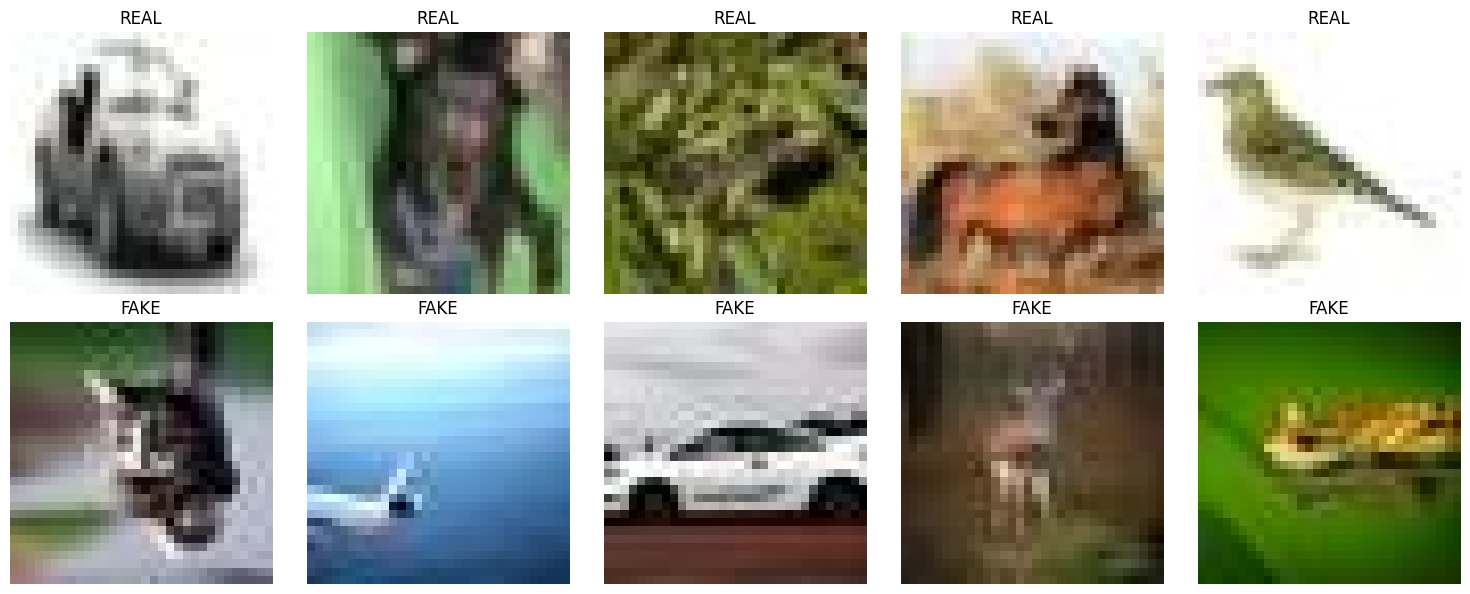

In [12]:
import matplotlib.pyplot as plt
from PIL import Image
import random

fig, axes = plt.subplots(2, 5, figsize=(15, 6))

classes = ["REAL", "FAKE"]

for row, class_name in enumerate(classes):

    class_folder = os.path.join(train_path, class_name)

    image_files = [
        f for f in os.listdir(class_folder)
        if f.lower().endswith((".png", ".jpg", ".jpeg"))
    ]

    selected_images = random.sample(image_files, 5)

    for col, image_file in enumerate(selected_images):

        image_path = os.path.join(class_folder, image_file)
        image = Image.open(image_path)

        axes[row, col].imshow(image)
        axes[row, col].set_title(class_name)
        axes[row, col].axis("off")

plt.tight_layout()
plt.show()

## 3.1 Dataset Distribution

The CIFAKE dataset contains two classes: REAL and FAKE.

The dataset is balanced across both classes:

| Dataset Split | REAL | FAKE | Total |
|--------------|------|------|-------|
| Training     | 50,000 | 50,000 | 100,000 |
| Testing      | 10,000 | 10,000 | 20,000 |

The balanced class distribution reduces the risk of class imbalance
affecting the comparison between the classification models.

Both models will use the same training and testing data to ensure a
fair performance comparison.

### Dataset Observation

The sample images show visual differences between real and
AI-generated images. However, these differences may be subtle and
difficult to identify reliably through manual inspection.

Therefore, deep learning models are used to automatically learn
discriminative visual features from the images.

The classification task is defined as:

- REAL → Class 0
- FAKE → Class 1

## 4. Data Preprocessing

Before training the models, the images are preprocessed to make them
suitable for deep learning.

The following preprocessing steps are applied:

1. Images are resized to a fixed resolution.
2. Pixel values are normalized to the range [0, 1].
3. The training data is divided into training and validation sets.
4. Images are grouped into mini-batches.
5. Prefetching is used to improve the training pipeline efficiency.

The same dataset split is used for both the CNN and MobileNetV2 models to ensure a fair performance comparison.

In [13]:
import tensorflow as tf
import os

print("TensorFlow version:", tf.__version__)

# Check GPU availability
print("GPU available:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 5. CNN Model from Scratch

A custom Convolutional Neural Network (CNN) is developed and trained
from scratch for binary classification of REAL and FAKE images.

The model does not use pretrained weights. All convolutional filters
are initialized and learned during training.

### CNN Architecture

Input Image (96 × 96 × 3)
        ↓
Convolutional Layer – 32 filters
        ↓
ReLU Activation
        ↓
Max Pooling
        ↓
Convolutional Layer – 64 filters
        ↓
ReLU Activation
        ↓
Max Pooling
        ↓
Convolutional Layer – 128 filters
        ↓
ReLU Activation
        ↓
Max Pooling
        ↓
Global Average Pooling
        ↓
Dense Layer
        ↓
Dropout
        ↓
Sigmoid Output
        ↓
REAL / FAKE

In [ ]:
from tensorflow.keras import layers, models

cnn_model = models.Sequential([

    # Input
    layers.Input(shape=(96, 96, 3)),

    # Block 1
    layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Block 2
    layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Block 3
    layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Feature aggregation
    layers.GlobalAveragePooling2D(),

    # Classification
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),

    # Binary output
    layers.Dense(1, activation="sigmoid")
])

cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 96, 96, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,889 (429.25 KB)

 Trainable params: 109,889 (429.25 KB)

 Non-trainable params: 0 (0.00 B)

### Model Compilation

The CNN is trained using the Adam optimizer and binary cross-entropy
loss because the task contains two classes: REAL and FAKE.

Accuracy is used as the primary training metric.

In [ ]:
cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("CNN model compiled successfully.")

CNN model compiled successfully.


In [ ]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

### CNN Training

The custom CNN is trained using the training dataset. The validation
dataset is used to monitor generalization during training.

The test dataset is kept separate and will only be used for final
evaluation.

In [ ]:
print(dataset_path)

/kaggle/input/cifake-real-and-ai-generated-synthetic-images


In [27]:
import os

train_path = os.path.join(dataset_path, "train")
test_path = os.path.join(dataset_path, "test")

print("Train path:", train_path)
print("Test path:", test_path)

Train path: /kaggle/input/cifake-real-and-ai-generated-synthetic-images/train
Test path: /kaggle/input/cifake-real-and-ai-generated-synthetic-images/test


In [ ]:
print(os.listdir(train_path))
print(os.listdir(test_path))

['FAKE', 'REAL']
['FAKE', 'REAL']


In [2]:
IMAGE_SIZE = (96, 96)
BATCH_SIZE = 64
VALIDATION_SPLIT = 0.10
SEED = 42

print("Image size:", IMAGE_SIZE)
print("Batch size:", BATCH_SIZE)

Image size: (96, 96)
Batch size: 64


In [14]:
import tensorflow as tf

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    labels="inferred",
    label_mode="binary",
    class_names=["REAL", "FAKE"],
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    validation_split=VALIDATION_SPLIT,
    subset="training",
    seed=SEED,
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    labels="inferred",
    label_mode="binary",
    class_names=["REAL", "FAKE"],
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    validation_split=VALIDATION_SPLIT,
    subset="validation",
    seed=SEED,
    shuffle=True
)

print("Training and validation datasets created.")

Found 100000 files belonging to 2 classes.
Using 90000 files for training.
Found 100000 files belonging to 2 classes.
Using 10000 files for validation.
Training and validation datasets created.


In [ ]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_path,
    labels="inferred",
    label_mode="binary",
    class_names=["REAL", "FAKE"],
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Test dataset created.")

Found 20000 files belonging to 2 classes.
Test dataset created.


In [ ]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(
    lambda x, y: (normalization_layer(x), y),
    num_parallel_calls=tf.data.AUTOTUNE
)

val_ds = val_ds.map(
    lambda x, y: (normalization_layer(x), y),
    num_parallel_calls=tf.data.AUTOTUNE
)

test_ds = test_ds.map(
    lambda x, y: (normalization_layer(x), y),
    num_parallel_calls=tf.data.AUTOTUNE
)

print("Normalization completed.")

Normalization completed.


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

print("Data pipeline ready.")

Data pipeline ready.


In [ ]:
print("train_ds:", train_ds)
print("val_ds:", val_ds)
print("test_ds:", test_ds)

train_ds: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 96, 96, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 1), dtype=tf.float32, name=None))>
val_ds: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 96, 96, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 1), dtype=tf.float32, name=None))>
test_ds: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 96, 96, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 1), dtype=tf.float32, name=None))>


In [ ]:
print(cnn_model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 96, 96, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,889 (429.25 KB)

 Trainable params: 109,889 (429.25 KB)

 Non-trainable params: 0 (0.00 B)

None


In [ ]:
print(early_stopping)
print(reduce_lr)

In [ ]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

In [ ]:
EPOCHS = 15

cnn_history = cnn_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[early_stopping, reduce_lr]
)

Epoch 1/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 353s 246ms/step - accuracy: 0.8041 - loss: 0.4200 - val_accuracy: 0.8784 - val_loss: 0.3021 - learning_rate: 0.0010
Epoch 2/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 64s 46ms/step - accuracy: 0.8814 - loss: 0.2855 - val_accuracy: 0.8971 - val_loss: 0.2507 - learning_rate: 0.0010
Epoch 3/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 65s 46ms/step - accuracy: 0.9055 - loss: 0.2354 - val_accuracy: 0.9214 - val_loss: 0.1954 - learning_rate: 0.0010
Epoch 4/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 64s 46ms/step - accuracy: 0.9197 - loss: 0.2035 - val_accuracy: 0.9281 - val_loss: 0.1816 - learning_rate: 0.0010
Epoch 5/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 63s 45ms/step - accuracy: 0.9285 - loss: 0.1849 - val_accuracy: 0.9306 - val_loss: 0.1763 - learning_rate: 0.0010
Epoch 6/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 64s 46ms/step - accuracy: 0.9329 - loss: 0.1724 - val_accuracy: 0.9366 - val_loss: 0.1609 - learning_rate: 0.0010
Epoch 7/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 63s 45ms/step - accu

In [ ]:
# CNN Test Evaluation

test_loss, test_accuracy = cnn_model.evaluate(test_ds, verbose=1)

print("CNN Test Loss:", test_loss)
print("CNN Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 62s 199ms/step - accuracy: 0.9562 - loss: 0.1179
CNN Test Loss: 0.1178690567612648
CNN Test Accuracy: 0.9562000036239624


### CNN Evaluation Result

The CNN model achieved a test accuracy of **95.62%** on the CIFAKE test dataset.

The model was further evaluated using precision, recall, F1-score and a confusion matrix to obtain a more detailed understanding of its classification performance.

In [ ]:
# CNN Detailed Evaluation - Correct Binary Classification

import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = cnn_model.predict(images, verbose=0)

    # Convert sigmoid probabilities to class labels
    predictions = (predictions.ravel() >= 0.5).astype(int)

    y_pred.extend(predictions)
    y_true.extend(labels.numpy())

y_true = np.array(y_true).astype(int)
y_pred = np.array(y_pred).astype(int)

print("CNN Classification Report")
print("=" * 60)

print(classification_report(
    y_true,
    y_pred,
    target_names=["FAKE", "REAL"],
    zero_division=0
))

CNN Classification Report
              precision    recall  f1-score   support

        FAKE       0.95      0.96      0.96     10000
        REAL       0.96      0.95      0.96     10000

    accuracy                           0.96     20000
   macro avg       0.96      0.96      0.96     20000
weighted avg       0.96      0.96      0.96     20000



Confusion Matrix:
[[9614  386]
 [ 490 9510]]


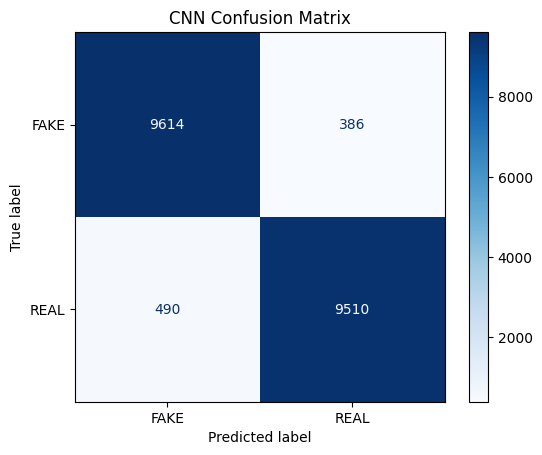

In [ ]:
# Correct CNN Confusion Matrix

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["FAKE", "REAL"]
)

disp.plot(cmap="Blues")
plt.title("CNN Confusion Matrix")
plt.show()

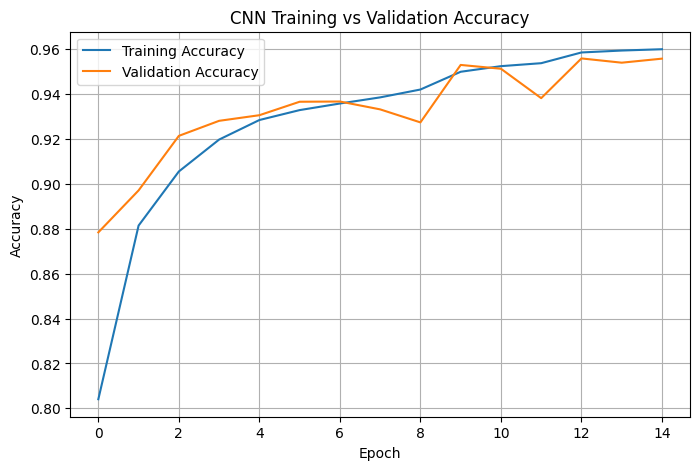

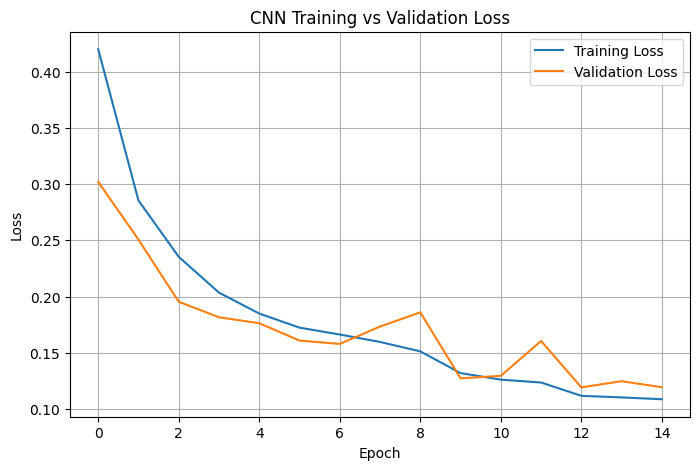

In [ ]:
# CNN Training and Validation Curves

import matplotlib.pyplot as plt

history = cnn_history.history

# Accuracy curve
plt.figure(figsize=(8, 5))
plt.plot(history["accuracy"], label="Training Accuracy")
plt.plot(history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# Loss curve
plt.figure(figsize=(8, 5))
plt.plot(history["loss"], label="Training Loss")
plt.plot(history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

### CNN Training Analysis

The training and validation loss curves show that the CNN learns effectively as the number of epochs increases. The training loss decreases consistently from approximately 0.42 to 0.11, while the validation loss decreases from approximately 0.30 to 0.12.

Although the validation loss shows some fluctuations during the middle epochs, it decreases overall and remains relatively close to the training loss toward the end of training. This indicates that the model converges well without severe overfitting.

The final test accuracy of the CNN is 95.62%, demonstrating strong classification performance on unseen test images.

## 7. Transfer Learning using MobileNetV2

MobileNetV2 is used as a transfer learning model for comparison with
the CNN trained from scratch.

A pretrained MobileNetV2 model trained on ImageNet is used as the
feature extractor. The original classification layer is removed and
a new binary classification head is added for FAKE and REAL image
classification.

Initially, the pretrained convolutional layers are frozen and only
the newly added classification layers are trained.

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [ ]:
IMG_SIZE = (224, 224)

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

# Freeze pretrained layers
base_model.trainable = False

mobilenet_model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid")
])

mobilenet_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
mobilenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("MobileNetV2 model compiled successfully.")

MobileNetV2 model compiled successfully.


In [ ]:
# ============================================================
# MobileNetV2 Transfer Learning Model
# ============================================================

import tensorflow as tf

# Create MobileNetV2 with the same image size as our dataset
mobilenet_base = tf.keras.applications.MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(96, 96, 3)
)

# Freeze pretrained layers
mobilenet_base.trainable = False

# Build the complete model
mobilenet_model = tf.keras.Sequential([
    mobilenet_base,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

# Compile model
mobilenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Display architecture
mobilenet_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
MOBILENET_EPOCHS = 10

mobilenet_history = mobilenet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=MOBILENET_EPOCHS
)

Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 106s 61ms/step - accuracy: 0.7373 - loss: 0.5256 - val_accuracy: 0.8391 - val_loss: 0.3661
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 65s 46ms/step - accuracy: 0.8328 - loss: 0.3706 - val_accuracy: 0.8618 - val_loss: 0.3260
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 65s 46ms/step - accuracy: 0.8519 - loss: 0.3365 - val_accuracy: 0.8691 - val_loss: 0.3089
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 69s 49ms/step - accuracy: 0.8595 - loss: 0.3230 - val_accuracy: 0.8742 - val_loss: 0.2997
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 65s 46ms/step - accuracy: 0.8633 - loss: 0.3152 - val_accuracy: 0.8767 - val_loss: 0.2923
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 64s 46ms/step - accuracy: 0.8668 - loss: 0.3089 - val_accuracy: 0.8785 - val_loss: 0.2886
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 64s 46ms/step - accuracy: 0.8683 - loss: 0.3061 - val_accuracy: 0.8789 - val_loss: 0.2850
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 64s 46ms/step - accuracy: 0.8691 

In [ ]:
# ============================================================
# MobileNetV2 Test Evaluation
# ============================================================

mobilenet_test_loss, mobilenet_test_accuracy = mobilenet_model.evaluate(
    test_ds,
    verbose=1
)

print("MobileNetV2 Test Loss:", mobilenet_test_loss)
print("MobileNetV2 Test Accuracy:", mobilenet_test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 35s 110ms/step - accuracy: 0.8884 - loss: 0.2731
MobileNetV2 Test Loss: 0.27311670780181885
MobileNetV2 Test Accuracy: 0.8883500099182129


In [ ]:
# ============================================================
# MobileNetV2 Detailed Evaluation
# ============================================================

import numpy as np
from sklearn.metrics import classification_report

y_true_mobilenet = []
y_pred_mobilenet = []

for images, labels in test_ds:
    predictions = mobilenet_model.predict(images, verbose=0)

    # Sigmoid probability -> binary class
    predictions = (predictions.ravel() >= 0.5).astype(int)

    y_pred_mobilenet.extend(predictions)
    y_true_mobilenet.extend(labels.numpy())

y_true_mobilenet = np.array(y_true_mobilenet).astype(int)
y_pred_mobilenet = np.array(y_pred_mobilenet).astype(int)

print("MobileNetV2 Classification Report")
print("=" * 60)

print(classification_report(
    y_true_mobilenet,
    y_pred_mobilenet,
    target_names=["FAKE", "REAL"],
    zero_division=0
))

MobileNetV2 Classification Report
              precision    recall  f1-score   support

        FAKE       0.89      0.88      0.89     10000
        REAL       0.88      0.90      0.89     10000

    accuracy                           0.89     20000
   macro avg       0.89      0.89      0.89     20000
weighted avg       0.89      0.89      0.89     20000



MobileNetV2 Confusion Matrix:
[[8803 1197]
 [1036 8964]]


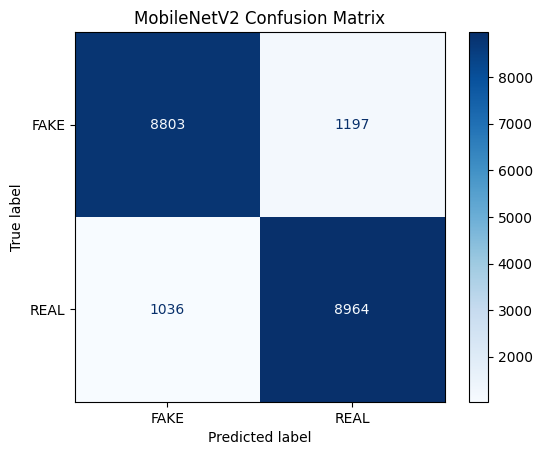

In [ ]:
# ============================================================
# MobileNetV2 Confusion Matrix
# ============================================================

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_mobilenet = confusion_matrix(
    y_true_mobilenet,
    y_pred_mobilenet
)

print("MobileNetV2 Confusion Matrix:")
print(cm_mobilenet)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_mobilenet,
    display_labels=["FAKE", "REAL"]
)

disp.plot(cmap="Blues")
plt.title("MobileNetV2 Confusion Matrix")
plt.show()

In [ ]:
# ============================================================
# MobileNetV2 Fine-Tuning
# ============================================================

# Unfreeze the MobileNetV2 base model
mobilenet_base.trainable = True

# Freeze the earlier layers and fine-tune only the last layers
for layer in mobilenet_base.layers[:-30]:
    layer.trainable = False

# Recompile with a very small learning rate
mobilenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Fine-tune the model
FINE_TUNE_EPOCHS = 5

mobilenet_finetune_history = mobilenet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=FINE_TUNE_EPOCHS
)

Epoch 1/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 111s 60ms/step - accuracy: 0.8443 - loss: 0.5877 - val_accuracy: 0.8746 - val_loss: 0.3124
Epoch 2/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 66s 47ms/step - accuracy: 0.9170 - loss: 0.2224 - val_accuracy: 0.9261 - val_loss: 0.1952
Epoch 3/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 68s 48ms/step - accuracy: 0.9324 - loss: 0.1759 - val_accuracy: 0.9353 - val_loss: 0.1728
Epoch 4/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 66s 47ms/step - accuracy: 0.9432 - loss: 0.1460 - val_accuracy: 0.9376 - val_loss: 0.1690
Epoch 5/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 65s 47ms/step - accuracy: 0.9515 - loss: 0.1253 - val_accuracy: 0.9425 - val_loss: 0.1533


In [ ]:
# ============================================================
# Final MobileNetV2 Evaluation After Fine-Tuning
# ============================================================

mobilenet_ft_loss, mobilenet_ft_accuracy = mobilenet_model.evaluate(
    test_ds,
    verbose=1
)

print("Fine-Tuned MobileNetV2 Test Loss:", mobilenet_ft_loss)
print("Fine-Tuned MobileNetV2 Test Accuracy:", mobilenet_ft_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 23s 74ms/step - accuracy: 0.9480 - loss: 0.1413
Fine-Tuned MobileNetV2 Test Loss: 0.14132916927337646
Fine-Tuned MobileNetV2 Test Accuracy: 0.9480000138282776


In [ ]:
# ============================================================
# Final Fine-Tuned MobileNetV2 Classification Report
# ============================================================

y_true_ft = []
y_pred_ft = []

for images, labels in test_ds:
    predictions = mobilenet_model.predict(images, verbose=0)

    predictions = (predictions.ravel() >= 0.5).astype(int)

    y_pred_ft.extend(predictions)
    y_true_ft.extend(labels.numpy())

y_true_ft = np.array(y_true_ft).astype(int)
y_pred_ft = np.array(y_pred_ft).astype(int)

print("Fine-Tuned MobileNetV2 Classification Report")
print("=" * 60)

print(classification_report(
    y_true_ft,
    y_pred_ft,
    target_names=["FAKE", "REAL"],
    zero_division=0
))

Fine-Tuned MobileNetV2 Classification Report
              precision    recall  f1-score   support

        FAKE       0.96      0.94      0.95     10000
        REAL       0.94      0.96      0.95     10000

    accuracy                           0.95     20000
   macro avg       0.95      0.95      0.95     20000
weighted avg       0.95      0.95      0.95     20000



Fine-Tuned MobileNetV2 Confusion Matrix:
[[9396  604]
 [ 436 9564]]


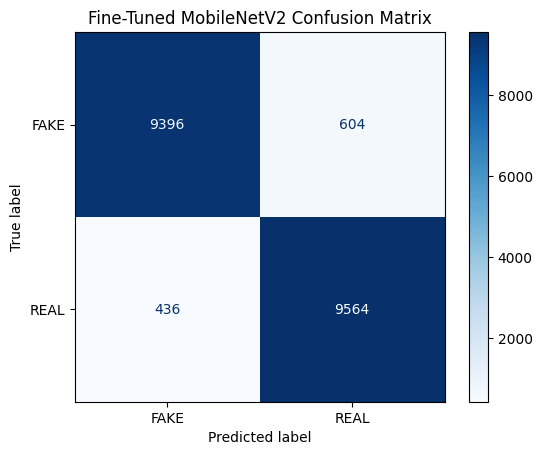

In [ ]:
# ============================================================
# Final Fine-Tuned MobileNetV2 Confusion Matrix
# ============================================================

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_ft = confusion_matrix(
    y_true_ft,
    y_pred_ft
)

print("Fine-Tuned MobileNetV2 Confusion Matrix:")
print(cm_ft)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_ft,
    display_labels=["FAKE", "REAL"]
)

disp.plot(cmap="Blues")
plt.title("Fine-Tuned MobileNetV2 Confusion Matrix")
plt.show()

## 8. ResNet50 Transfer Learning

ResNet50 is used as the third model to provide an additional independent
CNN architecture for comparison.

A pretrained ResNet50 model with ImageNet weights is used as the feature
extractor. Initially, the pretrained layers are frozen and a new binary
classification head is trained for REAL/FAKE classification.

After the initial transfer-learning stage, selected upper layers are
unfrozen and the model is fine-tuned using a smaller learning rate.

In [16]:
# ============================================================
# ResNet50 Preprocessing Pipeline
# ============================================================

# Train and validation datasets already exist
resnet_train_ds = train_ds.map(
    lambda images, labels: (
        tf.keras.applications.resnet50.preprocess_input(images * 255.0),
        labels
    ),
    num_parallel_calls=tf.data.AUTOTUNE
).prefetch(tf.data.AUTOTUNE)

resnet_val_ds = val_ds.map(
    lambda images, labels: (
        tf.keras.applications.resnet50.preprocess_input(images * 255.0),
        labels
    ),
    num_parallel_calls=tf.data.AUTOTUNE
).prefetch(tf.data.AUTOTUNE)

# Create the test dataset separately because test_ds is not
# currently available in the runtime
resnet_raw_test_ds = tf.keras.utils.image_dataset_from_directory(
    test_path,
    labels="inferred",
    label_mode="binary",
    class_names=["REAL", "FAKE"],
    image_size=(96, 96),
    batch_size=64,
    shuffle=False
)

resnet_test_ds = resnet_raw_test_ds.map(
    lambda images, labels: (
        tf.keras.applications.resnet50.preprocess_input(images * 255.0),
        labels
    ),
    num_parallel_calls=tf.data.AUTOTUNE
).prefetch(tf.data.AUTOTUNE)

print("ResNet50 preprocessing pipeline is ready.")

Found 20000 files belonging to 2 classes.
ResNet50 preprocessing pipeline is ready.


In [17]:
# ============================================================
# ResNet50 Transfer Learning Model
# ============================================================

import tensorflow as tf

resnet50_base = tf.keras.applications.ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(96, 96, 3)
)

# Freeze pretrained layers
resnet50_base.trainable = False

# Build the complete model
resnet50_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(96, 96, 3)),
    resnet50_base,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

# Compile the model
resnet50_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("ResNet50 model compiled successfully.")

resnet50_model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
ResNet50 model compiled successfully.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 3, 3, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         2,049 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,589,761 (89.99 MB)

 Trainable params: 2,049 (8.00 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [18]:
# ============================================================
# ResNet50 Initial Transfer Learning Training
# ============================================================

RESNET_EPOCHS = 10

resnet50_history = resnet50_model.fit(
    resnet_train_ds,
    validation_data=resnet_val_ds,
    epochs=RESNET_EPOCHS
)

Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 316s 214ms/step - accuracy: 0.5363 - loss: 108.8194 - val_accuracy: 0.6608 - val_loss: 20.5439
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 67s 48ms/step - accuracy: 0.5896 - loss: 43.3798 - val_accuracy: 0.7072 - val_loss: 9.7624
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 72s 51ms/step - accuracy: 0.6307 - loss: 18.0738 - val_accuracy: 0.6858 - val_loss: 7.4080
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 68s 48ms/step - accuracy: 0.6582 - loss: 8.8982 - val_accuracy: 0.6950 - val_loss: 4.4111
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 69s 49ms/step - accuracy: 0.6741 - loss: 5.1215 - val_accuracy: 0.7763 - val_loss: 1.5813
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 67s 48ms/step - accuracy: 0.6856 - loss: 3.2257 - val_accuracy: 0.7786 - val_loss: 1.1420
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 68s 48ms/step - accuracy: 0.6912 - loss: 2.2715 - val_accuracy: 0.7756 - val_loss: 0.8801
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 68s 49ms/step - accuracy: 0

In [19]:
# ============================================================
# ResNet50 Initial Test Evaluation
# ============================================================

resnet50_test_loss, resnet50_test_accuracy = resnet50_model.evaluate(
    resnet_test_ds,
    verbose=1
)

print("ResNet50 Test Loss:", resnet50_test_loss)
print("ResNet50 Test Accuracy:", resnet50_test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 63s 200ms/step - accuracy: 0.7664 - loss: 0.6044
ResNet50 Test Loss: 0.6044053435325623
ResNet50 Test Accuracy: 0.7664499878883362


In [20]:
# ============================================================
# ResNet50 Classification Report
# ============================================================

import numpy as np
from sklearn.metrics import classification_report

y_true_resnet = []
y_pred_resnet = []

for images, labels in resnet_test_ds:

    predictions = resnet50_model.predict(
        images,
        verbose=0
    )

    # Convert sigmoid probability to class label
    predictions = (predictions.ravel() >= 0.5).astype(int)

    y_pred_resnet.extend(predictions)
    y_true_resnet.extend(
        labels.numpy().reshape(-1).astype(int)
    )

y_true_resnet = np.array(y_true_resnet)
y_pred_resnet = np.array(y_pred_resnet)

print("ResNet50 Classification Report")
print("=" * 60)

print(
    classification_report(
        y_true_resnet,
        y_pred_resnet,
        target_names=["FAKE", "REAL"],
        zero_division=0
    )
)

ResNet50 Classification Report
              precision    recall  f1-score   support

        FAKE       0.73      0.85      0.78     10000
        REAL       0.82      0.69      0.75     10000

    accuracy                           0.77     20000
   macro avg       0.77      0.77      0.76     20000
weighted avg       0.77      0.77      0.76     20000



ResNet50 Confusion Matrix:
[[8455 1545]
 [3126 6874]]


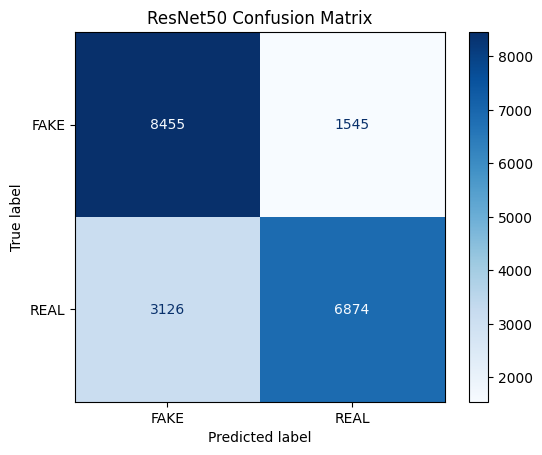

In [21]:
# ============================================================
# ResNet50 Confusion Matrix
# ============================================================

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_resnet50 = confusion_matrix(
    y_true_resnet,
    y_pred_resnet
)

print("ResNet50 Confusion Matrix:")
print(cm_resnet50)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_resnet50,
    display_labels=["FAKE", "REAL"]
)

disp.plot(cmap="Blues")
plt.title("ResNet50 Confusion Matrix")
plt.show()

In [22]:
# ============================================================
# ResNet50 Fine-Tuning
# ============================================================

# Unfreeze the ResNet50 base model
resnet50_base.trainable = True

# Freeze earlier layers and fine-tune only the last 30 layers
for layer in resnet50_base.layers[:-30]:
    layer.trainable = False

# Recompile with a smaller learning rate
resnet50_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("ResNet50 fine-tuning model compiled successfully.")

# Fine-tune
RESNET_FT_EPOCHS = 5

resnet50_finetune_history = resnet50_model.fit(
    resnet_train_ds,
    validation_data=resnet_val_ds,
    epochs=RESNET_FT_EPOCHS
)

ResNet50 fine-tuning model compiled successfully.
Epoch 1/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 123s 71ms/step - accuracy: 0.8077 - loss: 0.4081 - val_accuracy: 0.8499 - val_loss: 0.3369
Epoch 2/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 85s 60ms/step - accuracy: 0.8832 - loss: 0.2742 - val_accuracy: 0.8864 - val_loss: 0.2670
Epoch 3/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 142s 60ms/step - accuracy: 0.9062 - loss: 0.2255 - val_accuracy: 0.8910 - val_loss: 0.2569
Epoch 4/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 85s 60ms/step - accuracy: 0.9222 - loss: 0.1904 - val_accuracy: 0.9013 - val_loss: 0.2426
Epoch 5/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 84s 60ms/step - accuracy: 0.9330 - loss: 0.1623 - val_accuracy: 0.9017 - val_loss: 0.2591


In [24]:
# ============================================================
# Fine-Tuned ResNet50 Classification Report
# ============================================================

import numpy as np
from sklearn.metrics import classification_report

y_true_resnet_ft = []
y_pred_resnet_ft = []

for images, labels in resnet_test_ds:

    predictions = resnet50_model.predict(
        images,
        verbose=0
    )

    # Convert sigmoid probabilities to binary labels
    predictions = (predictions.ravel() >= 0.5).astype(int)

    y_pred_resnet_ft.extend(predictions)
    y_true_resnet_ft.extend(
        labels.numpy().reshape(-1).astype(int)
    )

y_true_resnet_ft = np.array(y_true_resnet_ft)
y_pred_resnet_ft = np.array(y_pred_resnet_ft)

print("Fine-Tuned ResNet50 Classification Report")
print("=" * 60)

print(
    classification_report(
        y_true_resnet_ft,
        y_pred_resnet_ft,
        target_names=["FAKE", "REAL"],
        zero_division=0
    )
)

Fine-Tuned ResNet50 Classification Report
              precision    recall  f1-score   support

        FAKE       0.92      0.87      0.89     10000
        REAL       0.87      0.93      0.90     10000

    accuracy                           0.90     20000
   macro avg       0.90      0.90      0.90     20000
weighted avg       0.90      0.90      0.90     20000



Fine-Tuned ResNet50 Confusion Matrix:
[[8669 1331]
 [ 708 9292]]


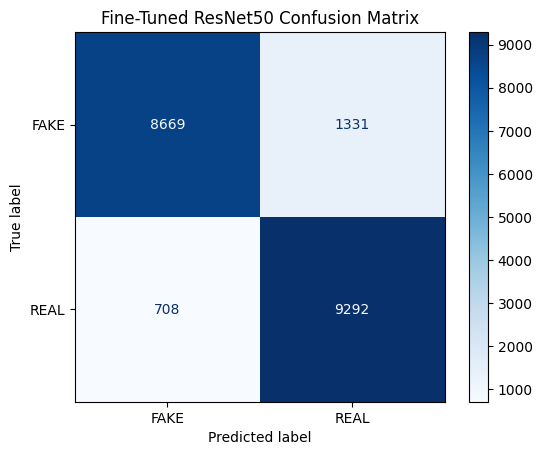

In [25]:
# ============================================================
# Fine-Tuned ResNet50 Confusion Matrix
# ============================================================

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_resnet_ft = confusion_matrix(
    y_true_resnet_ft,
    y_pred_resnet_ft
)

print("Fine-Tuned ResNet50 Confusion Matrix:")
print(cm_resnet_ft)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_resnet_ft,
    display_labels=["FAKE", "REAL"]
)

disp.plot(cmap="Blues")
plt.title("Fine-Tuned ResNet50 Confusion Matrix")
plt.show()

In [23]:
# ============================================================
# Fine-Tuned ResNet50 Test Evaluation
# ============================================================

resnet50_ft_loss, resnet50_ft_accuracy = resnet50_model.evaluate(
    resnet_test_ds,
    verbose=1
)

print("Fine-Tuned ResNet50 Test Loss:", resnet50_ft_loss)
print("Fine-Tuned ResNet50 Test Accuracy:", resnet50_ft_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 23s 73ms/step - accuracy: 0.8981 - loss: 0.2559
Fine-Tuned ResNet50 Test Loss: 0.2558788061141968
Fine-Tuned ResNet50 Test Accuracy: 0.8980500102043152


## ResNet50 Training and Validation Curves

The training and validation curves are analyzed to observe learning
progression, convergence and the effect of fine-tuning on ResNet50.


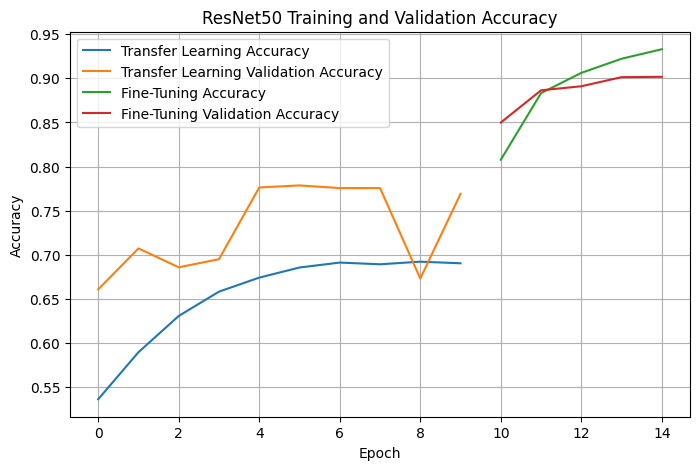

In [29]:
# ============================================================
# ResNet50 Training and Validation Accuracy
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    resnet50_history.history["accuracy"],
    label="Transfer Learning Accuracy"
)

plt.plot(
    resnet50_history.history["val_accuracy"],
    label="Transfer Learning Validation Accuracy"
)

plt.plot(
    range(
        len(resnet50_history.history["accuracy"]),
        len(resnet50_history.history["accuracy"]) +
        len(resnet50_finetune_history.history["accuracy"])
    ),
    resnet50_finetune_history.history["accuracy"],
    label="Fine-Tuning Accuracy"
)

plt.plot(
    range(
        len(resnet50_history.history["val_accuracy"]),
        len(resnet50_history.history["val_accuracy"]) +
        len(resnet50_finetune_history.history["val_accuracy"])
    ),
    resnet50_finetune_history.history["val_accuracy"],
    label="Fine-Tuning Validation Accuracy"
)

plt.title("ResNet50 Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

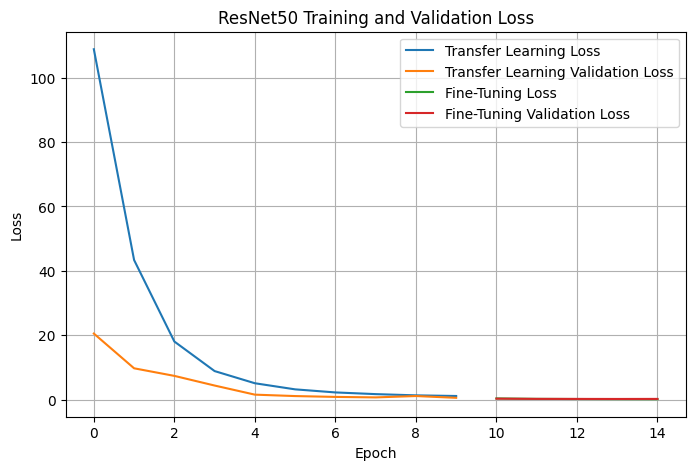

In [30]:
# ============================================================
# ResNet50 Training and Validation Loss
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    resnet50_history.history["loss"],
    label="Transfer Learning Loss"
)

plt.plot(
    resnet50_history.history["val_loss"],
    label="Transfer Learning Validation Loss"
)

plt.plot(
    range(
        len(resnet50_history.history["loss"]),
        len(resnet50_history.history["loss"]) +
        len(resnet50_finetune_history.history["loss"])
    ),
    resnet50_finetune_history.history["loss"],
    label="Fine-Tuning Loss"
)

plt.plot(
    range(
        len(resnet50_history.history["val_loss"]),
        len(resnet50_history.history["val_loss"]) +
        len(resnet50_finetune_history.history["val_loss"])
    ),
    resnet50_finetune_history.history["val_loss"],
    label="Fine-Tuning Validation Loss"
)

plt.title("ResNet50 Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

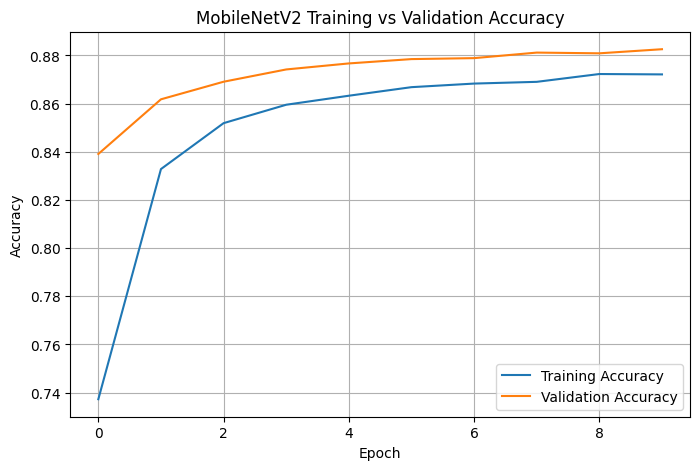

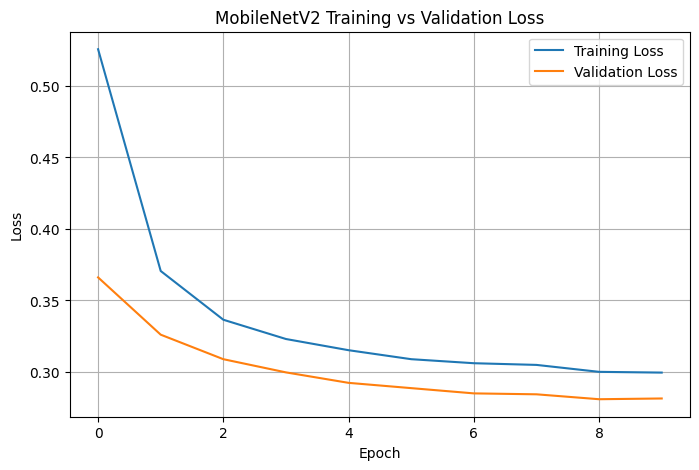

In [ ]:
# MobileNetV2 Training vs Validation Accuracy and Loss

import matplotlib.pyplot as plt

# Accuracy
plt.figure(figsize=(8, 5))
plt.plot(mobilenet_history.history['accuracy'], label='Training Accuracy')
plt.plot(mobilenet_history.history['val_accuracy'], label='Validation Accuracy')
plt.title('MobileNetV2 Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Loss
plt.figure(figsize=(8, 5))
plt.plot(mobilenet_history.history['loss'], label='Training Loss')
plt.plot(mobilenet_history.history['val_loss'], label='Validation Loss')
plt.title('MobileNetV2 Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

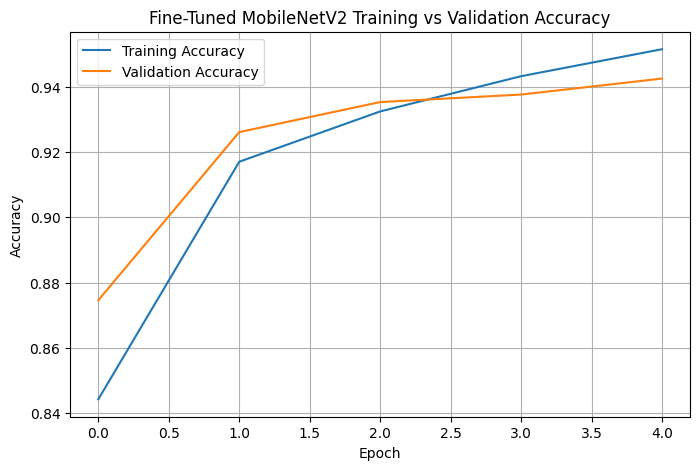

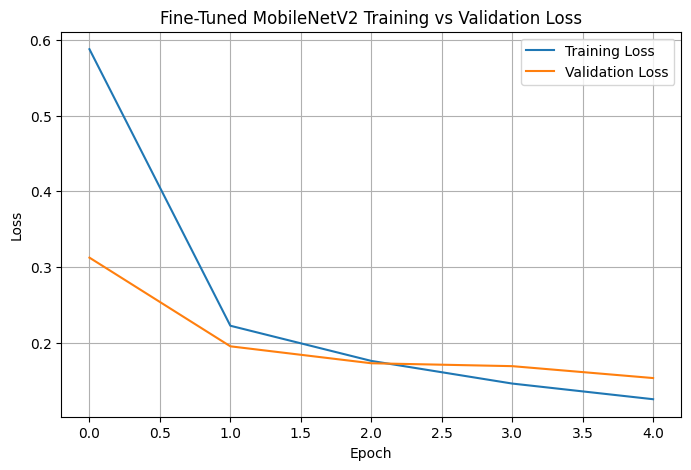

In [ ]:
# Fine-Tuned MobileNetV2 Training Curves

import matplotlib.pyplot as plt

# Accuracy
plt.figure(figsize=(8, 5))
plt.plot(
    mobilenet_finetune_history.history['accuracy'],
    label='Training Accuracy'
)
plt.plot(
    mobilenet_finetune_history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title('Fine-Tuned MobileNetV2 Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()


# Loss
plt.figure(figsize=(8, 5))
plt.plot(
    mobilenet_finetune_history.history['loss'],
    label='Training Loss'
)
plt.plot(
    mobilenet_finetune_history.history['val_loss'],
    label='Validation Loss'
)

plt.title('Fine-Tuned MobileNetV2 Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

,Model,Test Accuracy (%),Test Loss
0,Custom CNN,95.62,0.11787
1,Fine-Tuned MobileNetV2,94.80,0.14133
2,Fine-Tuned ResNet50,89.81,0.25588


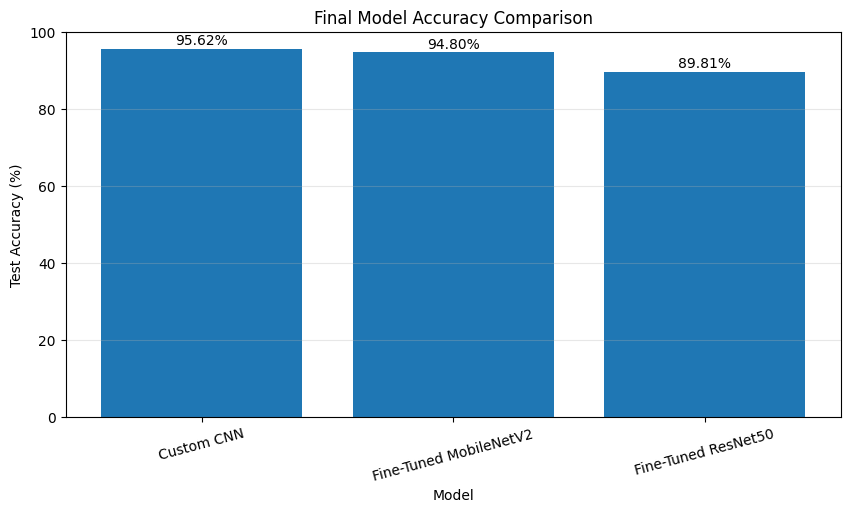

In [31]:
# ============================================================
# FINAL ARCHITECTURE COMPARISON
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

comparison = pd.DataFrame({
    "Model": [
        "Custom CNN",
        "Fine-Tuned MobileNetV2",
        "Fine-Tuned ResNet50"
    ],
    "Test Accuracy (%)": [
        95.62,
        94.80,
        89.81
    ],
    "Test Loss": [
        0.11787,
        0.14133,
        0.25588
    ]
})

display(comparison)

plt.figure(figsize=(10, 5))

bars = plt.bar(
    comparison["Model"],
    comparison["Test Accuracy (%)"]
)

plt.title("Final Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Test Accuracy (%)")
plt.ylim(0, 100)

for bar, value in zip(
    bars,
    comparison["Test Accuracy (%)"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 1,
        f"{value:.2f}%",
        ha="center"
    )

plt.xticks(rotation=15)
plt.grid(axis="y", alpha=0.3)
plt.show()

In [32]:
# ============================================================
# EFFECT OF FINE-TUNING
# ============================================================

finetuning_comparison = pd.DataFrame({
    "Model": [
        "MobileNetV2",
        "ResNet50"
    ],
    "Before Fine-Tuning (%)": [
        88.84,
        76.64
    ],
    "After Fine-Tuning (%)": [
        94.80,
        89.81
    ],
    "Improvement (percentage points)": [
        94.80 - 88.84,
        89.81 - 76.64
    ]
})

display(finetuning_comparison)

,Model,Before Fine-Tuning (%),After Fine-Tuning (%),Improvement (percentage points)
0,MobileNetV2,88.84,94.80,5.96
1,ResNet50,76.64,89.81,13.17


In [ ]:
# ============================================================
# Error Analysis - Fine-Tuned MobileNetV2
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

class_names = ["FAKE", "REAL"]

total_images = 0
correct = 0
incorrect = 0

wrong_images = []
wrong_true_labels = []
wrong_pred_labels = []

for images, labels in test_ds:

    # Model outputs sigmoid probabilities
    probabilities = mobilenet_model.predict(images, verbose=0).reshape(-1)

    # Convert probability to class
    predicted_labels = (probabilities >= 0.5).astype(np.int32)

    # Make labels one-dimensional
    true_labels = np.asarray(labels).reshape(-1).astype(np.int32)

    # Now both arrays have exactly the same shape: (batch_size,)
    for i in range(len(true_labels)):

        total_images += 1

        if predicted_labels[i] == true_labels[i]:
            correct += 1

        else:
            incorrect += 1

            # Keep only first 20 mistakes for visualization
            if len(wrong_images) < 20:
                wrong_images.append(images[i].numpy())
                wrong_true_labels.append(int(true_labels[i]))
                wrong_pred_labels.append(int(predicted_labels[i]))


print("Total test images:", total_images)
print("Correct predictions:", correct)
print("Incorrect predictions:", incorrect)
print("Error rate:", round((incorrect / total_images) * 100, 2), "%")

Total test images: 20000
Correct predictions: 18960
Incorrect predictions: 1040
Error rate: 5.2 %


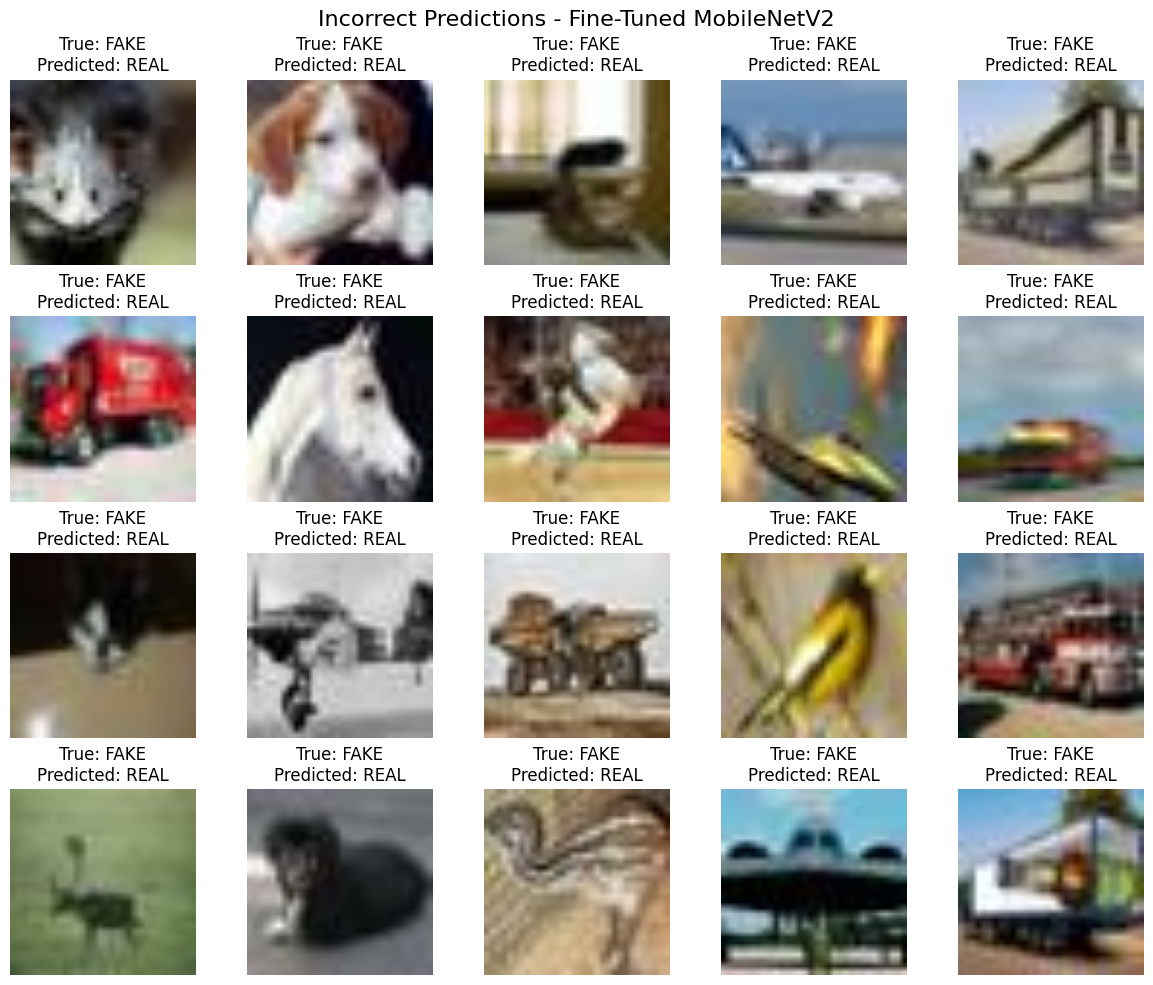

In [ ]:
# ============================================================
# Visualize Incorrect Predictions
# ============================================================

plt.figure(figsize=(12, 10))

for i in range(len(wrong_images)):

    plt.subplot(4, 5, i + 1)

    plt.imshow(wrong_images[i])

    plt.title(
        f"True: {class_names[wrong_true_labels[i]]}\n"
        f"Predicted: {class_names[wrong_pred_labels[i]]}"
    )

    plt.axis("off")

plt.suptitle(
    "Incorrect Predictions - Fine-Tuned MobileNetV2",
    fontsize=16
)

plt.tight_layout()
plt.show()

## Discussion and Results Analysis

Three different CNN architectures were evaluated on the same CIFAKE test
dataset: a custom CNN, fine-tuned MobileNetV2, and fine-tuned ResNet50.

The custom CNN achieved the highest test accuracy of **95.62%**.

MobileNetV2 achieved **88.84%** before fine-tuning and improved to
**94.80%** after fine-tuning, representing an improvement of
**5.96 percentage points**.

ResNet50 achieved **76.64%** before fine-tuning and improved to
**89.81%** after fine-tuning, representing an improvement of
**13.17 percentage points**.

The results show that fine-tuning substantially improved both pretrained
architectures. Among the final models, the fine-tuned MobileNetV2 produced
the strongest pretrained-model performance and was only **0.82 percentage
points** below the custom CNN.

Overall, the custom CNN performed best on this dataset, while transfer
learning and fine-tuning provided strong alternative approaches.

## Conclusion

This experiment implemented and compared three CNN architectures for binary
REAL/FAKE image classification: a custom CNN, MobileNetV2 and ResNet50.

The custom CNN achieved the highest test accuracy of **95.62%**.
MobileNetV2 improved from **88.84% to 94.80%** after fine-tuning, while
ResNet50 improved from **76.64% to 89.81%**.

These results demonstrate that pretrained models provide useful learned
features, while fine-tuning allows those features to adapt to the target
dataset.

Among the final models, the custom CNN achieved the highest accuracy, while
fine-tuned MobileNetV2 achieved the best performance among the pretrained
architectures.

## Research Paper Comparison

### Selected Research Paper

**Title:** A Comparative Study of MobileNetV2 and ResNet50 for Multi-Class
AI-Generated and Real Image Classification

### Comparison Between the Paper and Our Implementation

| Aspect | Research Paper | Our Implementation |
|---|---|---|
| Problem | AI-generated and real image classification | AI-generated (FAKE) vs REAL classification |
| Models | MobileNetV2 and ResNet50 | Custom CNN, MobileNetV2 and ResNet50 |
| MobileNetV2 | Used | Implemented |
| ResNet50 | Used | Implemented |
| Transfer Learning | Used | Used |
| Fine-Tuning | Used | Used |
| Classes | REAL/FAKE with visual subclasses | REAL and FAKE |
| Evaluation | Accuracy, Precision, Recall, F1-score, Confusion Matrix | Same |
| Best Model in Our Experiment | — | Custom CNN – 95.62% |

### Methodology Comparison

The research paper compares MobileNetV2 and ResNet50 using transfer learning
and fine-tuning for AI-generated and real image classification.

Our implementation adapts the research problem to binary REAL/FAKE
classification using the CIFAKE dataset. A custom CNN was also included as a
from-scratch baseline.

### Results of Our Implementation

| Model | Test Accuracy |
|---|---:|
| Custom CNN | **95.62%** |
| Fine-Tuned MobileNetV2 | **94.80%** |
| Fine-Tuned ResNet50 | **89.81%** |

The initial MobileNetV2 and ResNet50 accuracies were 88.84% and 76.64%,
respectively. Fine-tuning improved them to 94.80% and 89.81%.

### Similarities

- Both studies address AI-generated and real image classification.
- Both use CNN-based architectures.
- Both use MobileNetV2 and ResNet50.
- Transfer learning and fine-tuning are used.
- Model performance is evaluated quantitatively.

### Differences

- The research paper uses a more extensive multi-class setup with visual
  subclasses.
- Our implementation focuses on binary REAL/FAKE classification.
- The dataset and preprocessing configuration are different.
- The research paper uses 5-fold cross-validation and data augmentation,
  while our implementation uses a train/validation/test split.
- A custom CNN baseline is included in our implementation.

### Overall Observation

The research paper provided the basis for comparing MobileNetV2 and ResNet50.
Our implementation extended the experiment by including a custom CNN
baseline and by studying the effect of fine-tuning on both pretrained
architectures.

The custom CNN achieved the highest accuracy, while fine-tuned MobileNetV2
and ResNet50 demonstrated substantial improvements over their initial
transfer-learning performance.